# Does precinct order affect the unmixing?

Here we check whether the *order of the precinct columns* in `Y` plays a part in the
observed regionalism in archetypes. In exact arithmetic the whole pipeline
(est_noise → HySime → MVSA → SUNSAL) is permutation-equivariant in the precinct axis:
shuffling the columns of `Y` should permute the abundances identically and leave the
endmembers untouched. Any difference we see therefore comes from

1. floating-point non-associativity (summation order in matrix products) propagating
   through the SVDs and MVSA's iterative optimisation, and
2. data-dependent tie-breaks (e.g. argmax picks in VCA).

The only *explicit* randomness in the pipeline is VCA's random projection draws inside
MVSA's initialisation, driven by the global NumPy seed. To isolate ordering from
initialisation we run three arms against a common **reference run** (canonical order,
seed = config seed):

- **Arm A — determinism check:** canonical order, same seed, run twice. Should be
  bitwise identical; confirms the baseline is deterministic.
- **Arm B — order sensitivity (the question):** shuffled precinct order
  (`randomize_precinct_order=True` in preprocessing, a per-trial shuffle seed),
  **fixed** pipeline seed. Candidate/column order (senatorial, ranked by national
  total) is untouched by the shuffle. Abundances are mapped back to the reference
  precinct order before comparison.
- **Arm C — seed sensitivity (the yardstick):** canonical order, **varying** pipeline
  seed. Puts Arm B's variability in context: if B ≪ C, ordering is a non-issue
  relative to initialisation.

The whole design is run at **two archetype counts**: the config value (`p = 6`) and
**`p = 4`**, where notebook 08's sweep puts the minimum pairwise distance between
archetypes across metrics — i.e. the largest `p` whose archetypes stay mutually
distinct. If the instability seen at `p = 6` is degeneracy of the decomposition, it
should shrink substantially at `p = 4`.

Matching across runs is evaluated under a **suite of rank metrics** (Spearman ρ,
rank-biased overlap, weighted Kendall τ, top-12 Jaccard) plus cosine — see the
matching section for why.

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm

from scipy.stats import pearsonr

from src.config import load_config
from src.data import load_complete
from src.data.preprocessing import preprocess_from_config
from src.unmixing import est_noise, hysime, mvsa, sunsal_mod
from src.unmixing.matching import match_to_reference, similarity_matrix

sns.set_style('whitegrid')
config = load_config()

In [2]:
def run_pipeline(Y_in, p, seed, verbose=False):
    """Run the full unmixing pipeline on one vote matrix.

    est_noise -> HySime (signal-subspace estimate kf) -> MVSA (endmembers)
    -> SUNSAL (abundances), with MVSA/SUNSAL settings from the config.

    Parameters
    ----------
    Y_in : ndarray, shape (L, N)
        Vote matrix, candidates x precincts.
    p : int or None
        Number of archetypes; None uses the HySime estimate kf.
    seed : int
        Global NumPy seed set before the run; controls VCA's random
        projections inside MVSA's initialisation (the pipeline's only
        explicit randomness).
    verbose : bool, default False
        Print kf, the archetype count used, and the reconstruction RMSE.

    Returns
    -------
    result : dict
        ``endm`` (L, p) endmember loadings, ``abundances`` (p, N),
        ``kf`` HySime subspace estimate, ``n_arch`` archetype count used,
        ``rmse`` reconstruction root-mean-square error.
    """
    np.random.seed(seed)
    w_hat, Rw_hat = est_noise(Y_in, noise_type='additive', verbose=False)
    kf, Ek, E, delta_p = hysime(Y_in, w_hat, Rw_hat, verbose=False)
    n_arch = p or kf
    endm, Sest, Up, my, sing_values = mvsa(
        Y_in, p=n_arch,
        MM_iters=config['unmixing'].getint('mvsa_mm_iters'),
        spherize='yes', verbose=0)
    abundances, res_p, res_d = sunsal_mod(
        endm, Y_in, positivity='yes', addone='yes',
        AL_iters=config['unmixing'].getint('sunsal_al_iters'),
        lambda_=0.0, tol=config['unmixing'].getfloat('sunsal_tol'), verbose='no')
    Y_rec = endm @ abundances
    rmse = float(np.sqrt(np.mean((Y_in - Y_rec) ** 2)))
    if verbose:
        print(f'kf={kf}, n_arch={n_arch}, RMSE={rmse:.6f}')
    return {'endm': endm, 'abundances': abundances, 'kf': int(kf),
            'n_arch': int(n_arch), 'rmse': rmse}

In [3]:
SEED = config['unmixing'].getint('seed')   # pipeline (VCA/MVSA init) seed
PERM_SEED = 1000                           # separate stream for the precinct shuffles
P = config['unmixing'].getint('n_archetypes') or None
PS = [P, 4]        # config value, and nb08's min-pairwise-distance choice
n_trials = 10

df = load_complete(config)

# Canonical preprocessing: reference precinct order shared by all runs
pre_ref = preprocess_from_config(df, config)
Y_ref = pre_ref.Y
L, N = Y_ref.shape
candidate_labels = pre_ref.candidate_labels
ref_ids = pd.Index(pre_ref.params['precinct_ids'])

candidates: 66 -> 66 (25th pct >= 1.0)
precincts:  92,488 -> 92,487 (total votes >= 1.0)
Y: 66 candidates x 92,487 precincts (valid_ballots normalization)


In [4]:
def run_experiment(p_run):
    """Run the full order-sensitivity design at one archetype count.

    Reference run (canonical order, config seed), Arm B (shuffled precinct
    order, fixed seed), and Arm C (canonical order, varying seed).

    Parameters
    ----------
    p_run : int
        Number of archetypes passed to every pipeline run.

    Returns
    -------
    experiment : dict
        ``ref`` — reference `run_pipeline` result; ``B`` and ``C`` — lists of
        `n_trials` results. Arm B abundances are already mapped back to the
        reference precinct order, so all results are directly comparable.
    """
    ref = run_pipeline(Y_ref, p=p_run, seed=SEED)

    results_B = []
    for trial in tqdm.tqdm(range(n_trials), desc=f'p={p_run} Arm B (shuffled order)'):
        np.random.seed(PERM_SEED + trial)        # drives only the precinct shuffle
        pre = preprocess_from_config(df, config, randomize_precinct_order=True, verbose=False)
        assert pre.ranked_columns == pre_ref.ranked_columns   # candidate order untouched

        res = run_pipeline(pre.Y, p=p_run, seed=SEED)         # same pipeline seed as reference

        # abundances back into reference precinct order: trial column j is precinct
        # pre.params['precinct_ids'][j], which sits at position pos[j] in the reference
        pos = ref_ids.get_indexer(pre.params['precinct_ids'])
        assert (pos >= 0).all() and len(np.unique(pos)) == N
        A = np.empty_like(res['abundances'])
        A[:, pos] = res['abundances']
        res['abundances'] = A
        results_B.append(res)

    results_C = [run_pipeline(Y_ref, p=p_run, seed=SEED + 1 + t)   # offset: SEED is the reference
                 for t in tqdm.tqdm(range(n_trials), desc=f'p={p_run} Arm C (varying seed)')]

    return {'ref': ref, 'B': results_B, 'C': results_C}


exp = {p_run: run_experiment(p_run) for p_run in PS}

for p_run, e in exp.items():
    rmses = [e['ref']['rmse']] + [r['rmse'] for r in e['B']] + [r['rmse'] for r in e['C']]
    print(f"p={p_run}: ref RMSE={e['ref']['rmse']:.6f}, "
          f"RMSE range over all 21 runs: [{min(rmses):.6f}, {max(rmses):.6f}]")

SNR estimated = -inf[dB]
... Select the projective proj.


/Users/hannaharjonillo/Documents/UP/PhD Physics/repositories/voting-unmixing-ph/notebooks/../src/unmixing/endmember_extraction.py:259: UserWarning: sparse_svds failed, falling back to full SVD: `k` must be an integer satisfying `0 < k < min(A.shape)`.
  warnings.warn(f"sparse_svds failed, falling back to full SVD: {e}")
/Users/hannaharjonillo/Documents/UP/PhD Physics/repositories/voting-unmixing-ph/notebooks/../src/unmixing/endmember_extraction.py:157: UserWarning: SNR estimation: Denominator or numerator for log10 is non-positive. Returning -inf.
  warnings.warn(


p=6 Arm B (shuffled order):   0%|          | 0/10 [00:00<?, ?it/s]

/Users/hannaharjonillo/Documents/UP/PhD Physics/repositories/voting-unmixing-ph/notebooks/../src/unmixing/endmember_extraction.py:259: UserWarning: sparse_svds failed, falling back to full SVD: `k` must be an integer satisfying `0 < k < min(A.shape)`.
  warnings.warn(f"sparse_svds failed, falling back to full SVD: {e}")
/Users/hannaharjonillo/Documents/UP/PhD Physics/repositories/voting-unmixing-ph/notebooks/../src/unmixing/endmember_extraction.py:157: UserWarning: SNR estimation: Denominator or numerator for log10 is non-positive. Returning -inf.
  warnings.warn(


SNR estimated = -inf[dB]
... Select the projective proj.


...

p=4 Arm C (varying seed):  90%|█████████ | 9/10 [00:16<00:01,  1.71s/it]

SNR estimated = -inf[dB]
... Select the projective proj.


p=4 Arm C (varying seed): 100%|██████████| 10/10 [00:17<00:00,  1.64s/it]

p=4 Arm C (varying seed): 100%|██████████| 10/10 [00:17<00:00,  1.78s/it]

p=6: ref RMSE=0.033695, RMSE range over all 21 runs: [0.033695, 0.033696]
p=4: ref RMSE=0.038639, RMSE range over all 21 runs: [0.038639, 0.038639]


## Arm A — determinism check

Same data, same order, same seed, run again: must be bitwise identical to the reference,
otherwise there is uncontrolled randomness and the arms below are confounded.

In [5]:
rerun = run_pipeline(Y_ref, p=PS[0], seed=SEED)
ref0 = exp[PS[0]]['ref']

print('endmembers bitwise identical:', np.array_equal(ref0['endm'], rerun['endm']))
print('abundances bitwise identical:', np.array_equal(ref0['abundances'], rerun['abundances']))
print('max |Δ endm|:  ', np.abs(ref0['endm'] - rerun['endm']).max())
print('max |Δ abund|: ', np.abs(ref0['abundances'] - rerun['abundances']).max())

SNR estimated = -inf[dB]
... Select the projective proj.


endmembers bitwise identical: True
abundances bitwise identical: True
max |Δ endm|:   0.0
max |Δ abund|:  0.0


## Reference archetypes at each p

The canonical-order, config-seed solution each arm is compared against.

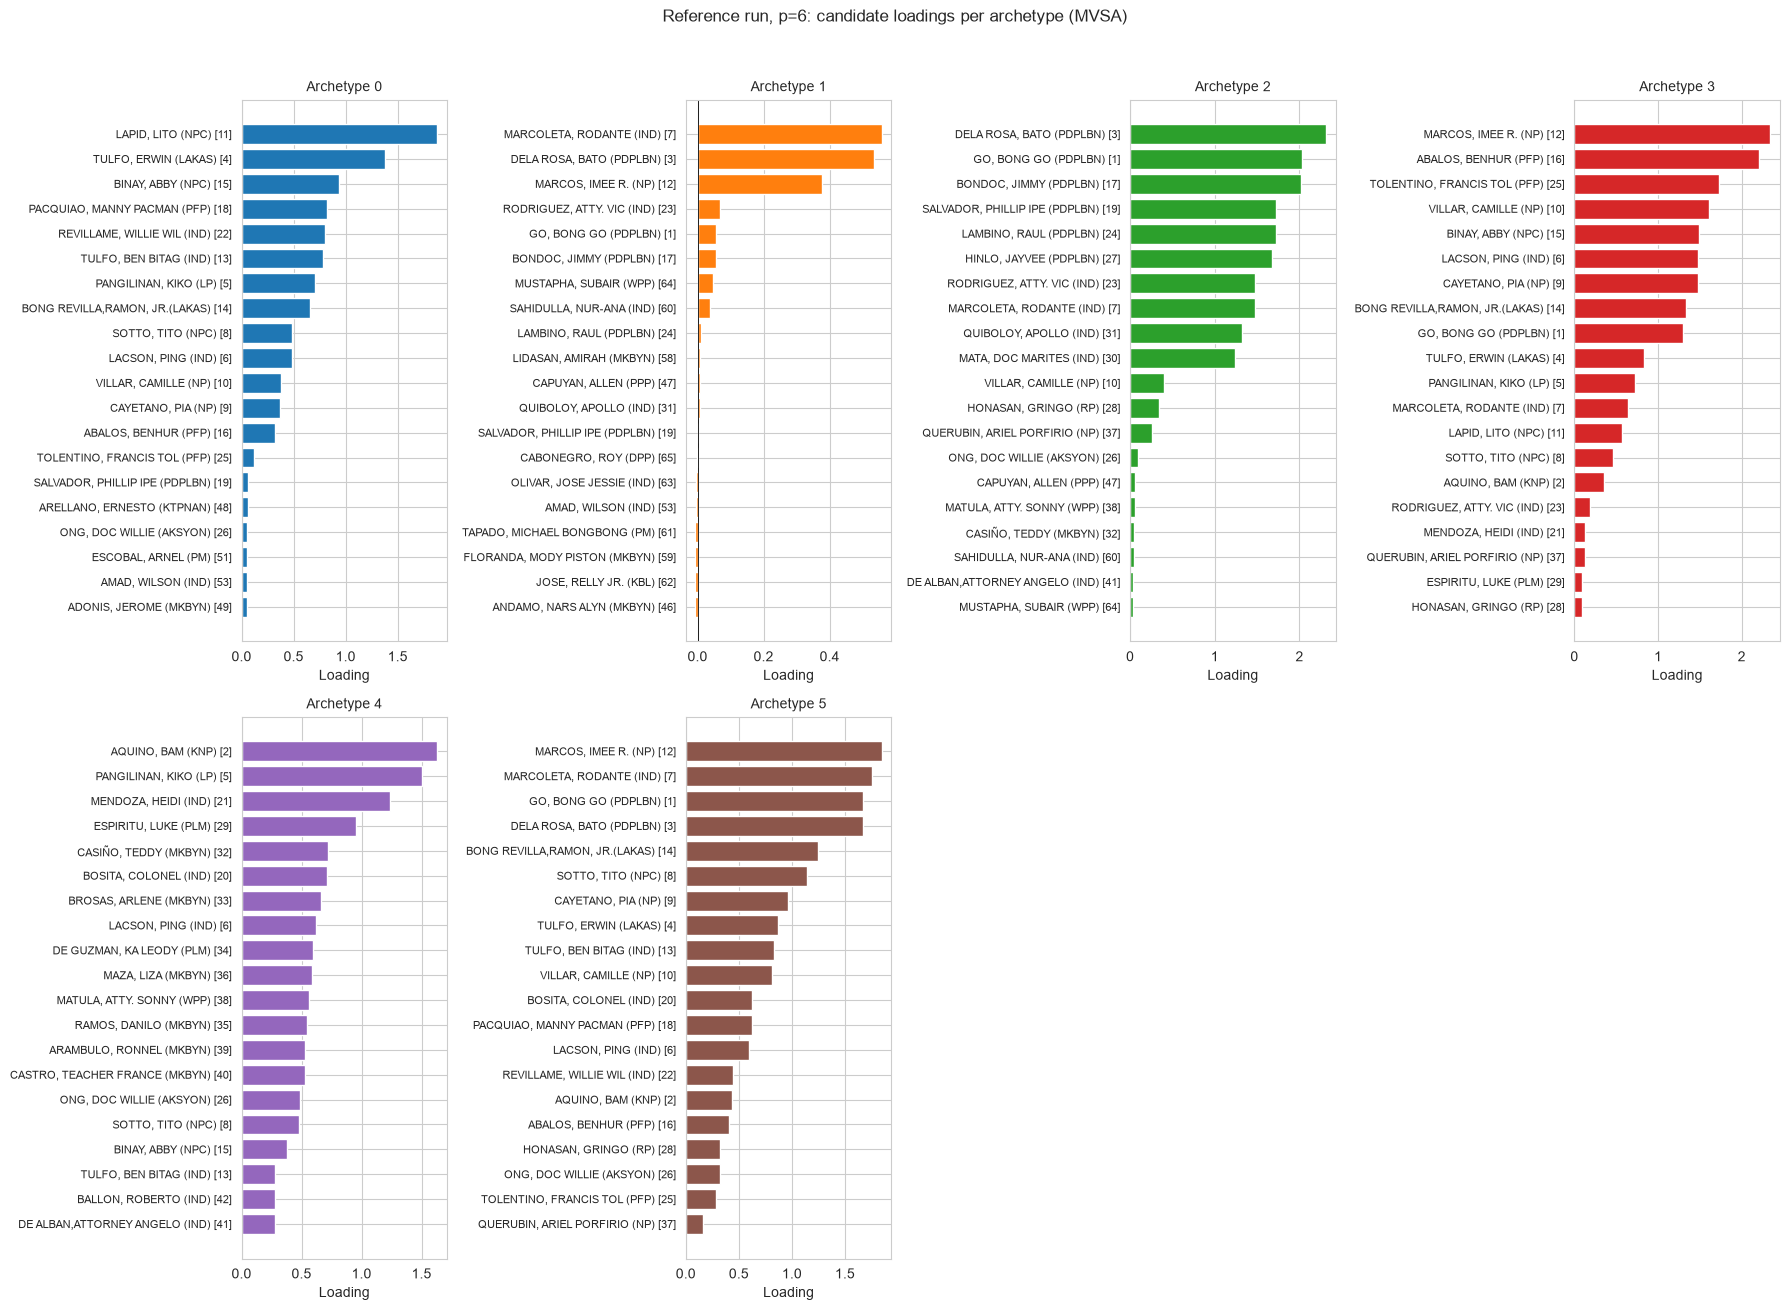

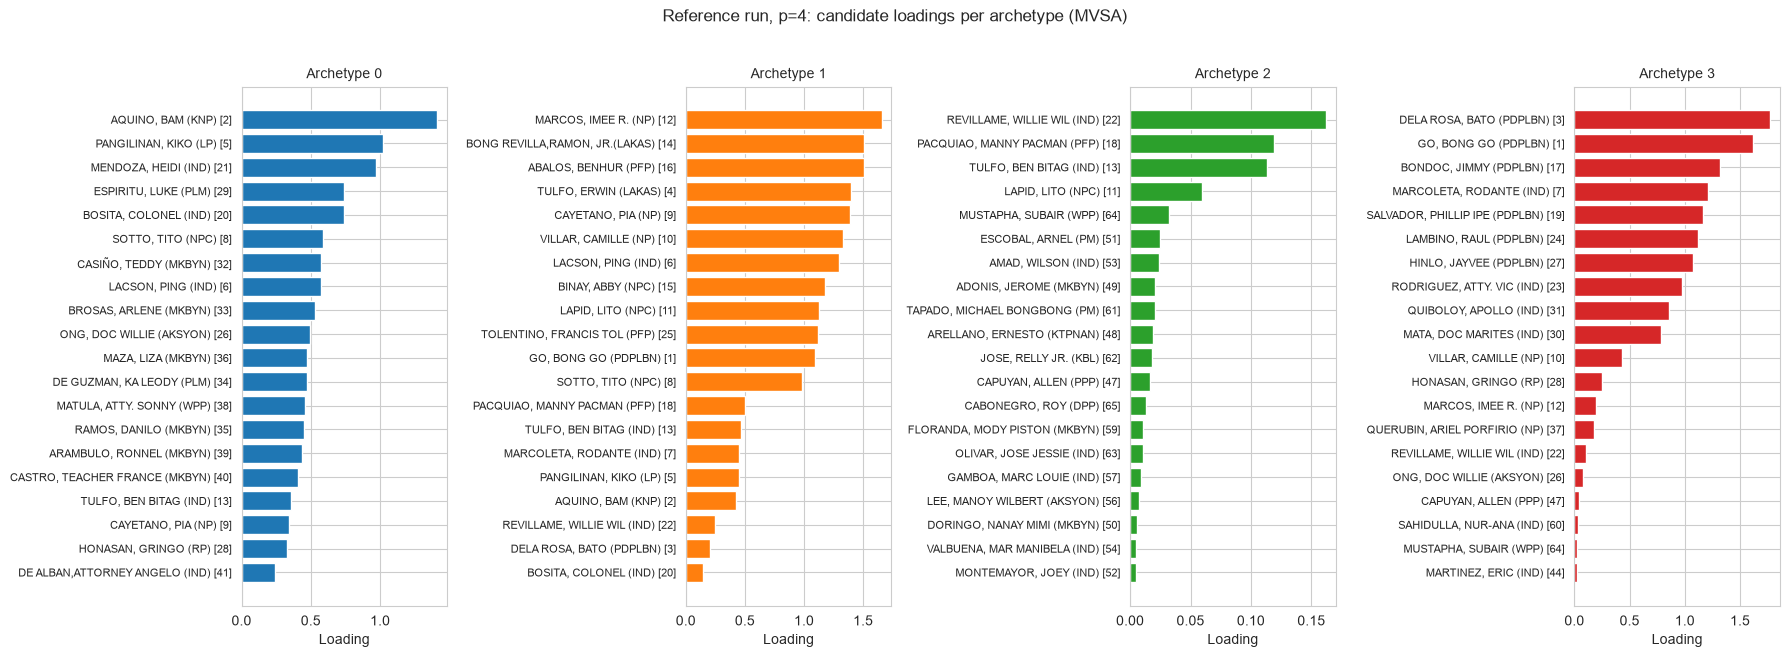

In [6]:
from src.figures import plot_archetypes_loadings_grid

for p_run in PS:
    plot_archetypes_loadings_grid(
        exp[p_run]['ref']['endm'], candidate_labels, top_n=20,
        suptitle=f'Reference run, p={p_run}: candidate loadings per archetype (MVSA)')

## Matching archetypes across trials

MVSA returns archetypes in arbitrary column order, so each trial must be aligned to the
reference before comparing. We use **Hungarian assignment** (`linear_sum_assignment`) on a
column-similarity matrix, evaluated under a suite of metrics (same definitions as
notebook 08, now in `src.unmixing.matching`):

- **Spearman ρ** — rank correlation over all 66 candidates, every rank weighted equally.
  Its weakness here: most of the ranking is the long tail of no-hope candidates, so
  agreement in the tail can mask disagreement among the candidates that actually define
  the archetype.
- **Rank-biased overlap (RBO**, extrapolated, `pval = 0.9`**)** — top-weighted set
  overlap at increasing depths; agreement among the top-ranked candidates counts most.
- **Weighted Kendall τ** (scipy, hyperbolic weights) — like Kendall τ but exchanges near
  the top cost more; a top-weighted take on the full ordering.
- **Top-12 Jaccard** — plain overlap of the top-12 candidate *sets*, order inside the set
  ignored. 12 = the number of senate seats, so this reads as "do the two archetypes
  elect the same slate?"
- **cosine** on the raw loadings, as the magnitude-aware second opinion.

*Why Hungarian?* It returns the one-to-one assignment maximising total similarity — the
right formulation when both runs have the same `p` and the archetypes should correspond.
Greedy argmax is kept as a *degeneracy diagnostic* (where it disagrees with Hungarian,
one trial archetype is the best match for two reference archetypes at once), along with
the margin to the runner-up similarity. A further diagnostic now available: whether the
**different metrics agree on the assignment itself** — if they don't, the correspondence
is ambiguous regardless of matcher.

In [7]:
METRICS = ['spearman', 'rbo', 'weighted_tau', 'top12_jaccard', 'cosine']


def match_trials(results, ref_endm, similarity):
    """Hungarian-match each trial's archetypes to the reference; flag ambiguity.

    Parameters
    ----------
    results : list of dict
        One arm's `run_pipeline` results.
    ref_endm : ndarray, shape (L, p)
        Reference endmember matrix the trials are aligned to.
    similarity : str
        Column-similarity metric driving the assignment; any name accepted
        by ``similarity_matrix``.

    Returns
    -------
    table : pandas.DataFrame
        One row per (trial, reference archetype): the matched trial
        archetype (``match``), its similarity (``sim``), the margin over the
        runner-up similarity in that row (``margin``; negative when the
        Hungarian pick is not the row-wise best), and whether greedy argmax
        agrees with the Hungarian assignment (``greedy_agrees``).
    perms : list of ndarray
        Per-trial permutations such that ``endm[:, perm]`` aligns to
        `ref_endm` column-wise.
    """
    rows, perms = [], []
    for t, res in enumerate(results):
        C = similarity_matrix(ref_endm, res['endm'], similarity)
        perm, sim = match_to_reference(ref_endm, res['endm'], similarity)
        greedy = C.argmax(axis=1)
        for k in range(len(perm)):
            runner_up = np.partition(C[k], -2)[-2]
            rows.append({'trial': t, 'archetype': k, 'match': int(perm[k]),
                         'sim': sim[k], 'margin': sim[k] - runner_up,
                         'greedy_agrees': bool(greedy[k] == perm[k])})
        perms.append(perm)
    return pd.DataFrame(rows), perms


matches = {(p_run, arm, metric): match_trials(exp[p_run][arm], exp[p_run]['ref']['endm'], metric)
           for p_run in PS for arm in ['B', 'C'] for metric in METRICS}

# Do the metrics agree on WHO matches WHOM? (fraction of assignments equal to spearman's)
print('assignment agreement with spearman / greedy agreement with Hungarian:')
for p_run in PS:
    for arm in ['B', 'C']:
        base = np.array(matches[p_run, arm, 'spearman'][1])
        agree = {m: float(np.mean([np.mean(perm == base[t])
                                   for t, perm in enumerate(matches[p_run, arm, m][1])]))
                 for m in METRICS if m != 'spearman'}
        greedy_ok = {m: matches[p_run, arm, m][0]['greedy_agrees'].mean() for m in METRICS}
        print(f'  p={p_run} arm {arm}: ' +
              ', '.join(f'{m}={v:.0%}' for m, v in agree.items()) +
              '  |  greedy: ' + ', '.join(f'{m}={v:.0%}' for m, v in greedy_ok.items()))

assignment agreement with spearman / greedy agreement with Hungarian:
  p=6 arm B: rbo=90%, weighted_tau=90%, top12_jaccard=90%, cosine=100%  |  greedy: spearman=93%, rbo=90%, weighted_tau=87%, top12_jaccard=85%, cosine=97%
  p=6 arm C: rbo=90%, weighted_tau=90%, top12_jaccard=87%, cosine=95%  |  greedy: spearman=82%, rbo=88%, weighted_tau=87%, top12_jaccard=83%, cosine=88%
  p=4 arm B: rbo=100%, weighted_tau=100%, top12_jaccard=100%, cosine=100%  |  greedy: spearman=100%, rbo=100%, weighted_tau=100%, top12_jaccard=100%, cosine=100%
  p=4 arm C: rbo=100%, weighted_tau=100%, top12_jaccard=100%, cosine=100%  |  greedy: spearman=100%, rbo=100%, weighted_tau=100%, top12_jaccard=100%, cosine=100%


In [8]:
# Matched similarity vs reference, aggregated over archetypes x trials
summ = pd.concat({key: m for key, (m, _) in matches.items()},
                 names=['p', 'arm', 'metric']) \
    .groupby(['p', 'arm', 'metric'])['sim'].agg(['mean', 'min'])
summ.unstack('arm').reindex(METRICS, level='metric').round(3)

mean           min       
arm                  B      C      B      C
p metric                                   
4 spearman       0.999  0.976  0.985  0.675
  rbo            0.995  0.944  0.925  0.627
  weighted_tau   0.997  0.967  0.984  0.739
  top12_jaccard  1.000  0.966  1.000  0.500
  cosine         1.000  0.977  0.995  0.582
6 spearman       0.847  0.781  0.198  0.153
  rbo            0.821  0.773  0.159  0.264
  weighted_tau   0.844  0.805  0.371  0.251
  top12_jaccard  0.784  0.746  0.143  0.143
  cosine         0.908  0.861  0.347  0.153

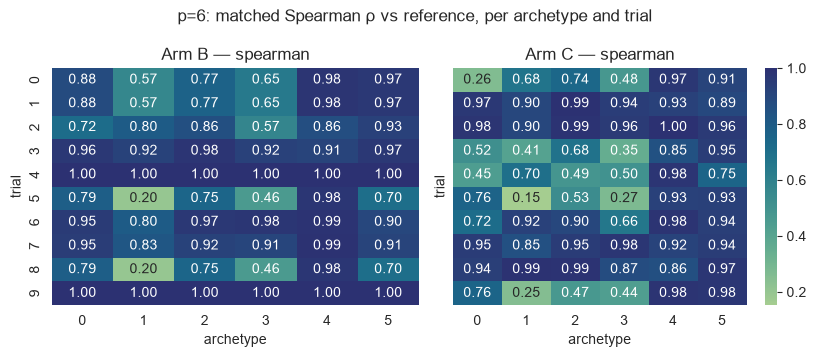

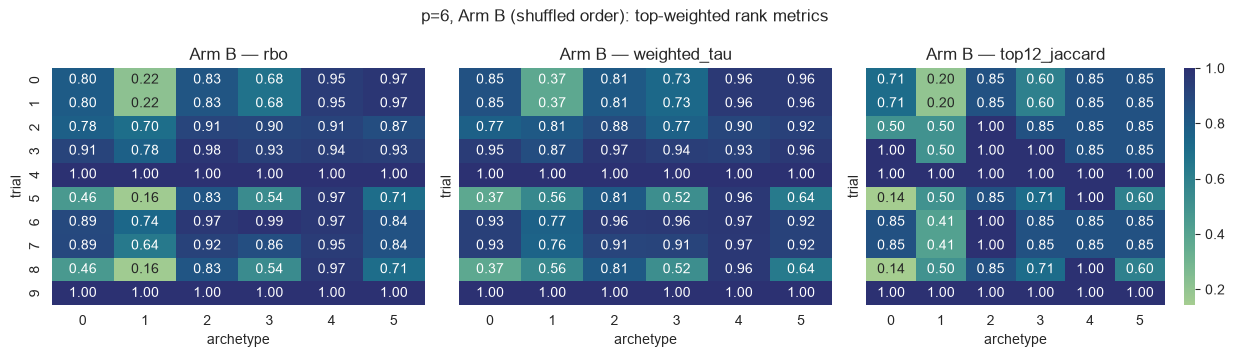

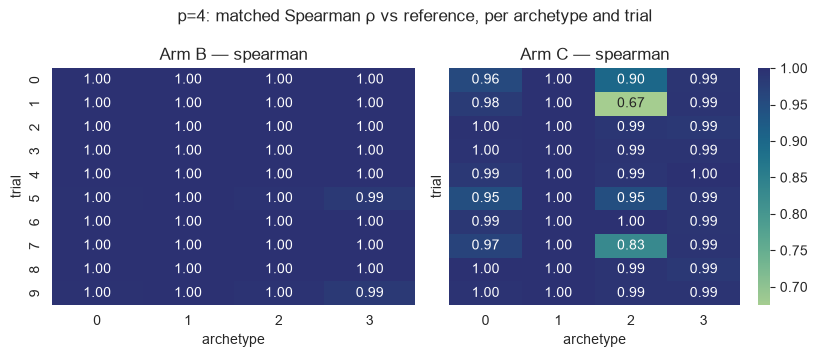

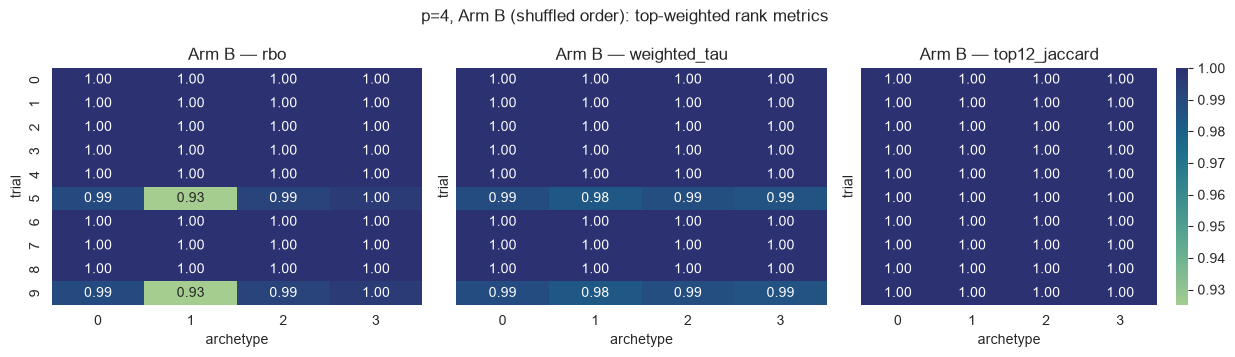

In [9]:
def heatmap_grid(p_run, arm_metric_pairs, suptitle):
    """Row of trial x archetype heatmaps of matched similarity.

    Parameters
    ----------
    p_run : int
        Which experiment (archetype count) to read from `matches`.
    arm_metric_pairs : list of (str, str)
        One heatmap per (arm, metric) pair, e.g. ``[('B', 'rbo'), ...]``.
        All panels share the colour scale (min over panels .. 1.0).
    suptitle : str
        Figure title.
    """
    n = len(arm_metric_pairs)
    fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 3.6), sharey=True)
    axes = np.atleast_1d(axes)
    pivs = [matches[p_run, arm, m][0].pivot(index='trial', columns='archetype', values='sim')
            for arm, m in arm_metric_pairs]
    vmin = min(piv.values.min() for piv in pivs)
    for ax, piv, (arm, m) in zip(axes, pivs, arm_metric_pairs):
        sns.heatmap(piv, annot=True, fmt='.2f', cmap='crest', vmin=vmin, vmax=1.0,
                    cbar=(ax is axes[-1]), ax=ax)
        ax.set_title(f'Arm {arm} — {m}')
    fig.suptitle(suptitle)
    fig.tight_layout()


for p_run in PS:
    heatmap_grid(p_run, [('B', 'spearman'), ('C', 'spearman')],
                 f'p={p_run}: matched Spearman ρ vs reference, per archetype and trial')
    heatmap_grid(p_run, [('B', 'rbo'), ('B', 'weighted_tau'), ('B', 'top12_jaccard')],
                 f'p={p_run}, Arm B (shuffled order): top-weighted rank metrics')

In [10]:
# Worst-case loading change per trial, after (spearman-)matching
for p_run in PS:
    print(f'p={p_run}  (scale: 99th pct of |reference loadings| = '
          f'{np.percentile(np.abs(exp[p_run]["ref"]["endm"]), 99):.4f})')
    for arm in ['B', 'C']:
        perms = matches[p_run, arm, 'spearman'][1]
        dev = np.array([np.abs(res['endm'][:, perm] - exp[p_run]['ref']['endm']).max()
                        for res, perm in zip(exp[p_run][arm], perms)])
        print(f'  Arm {arm}: max |Δ loading| per trial =', np.round(dev, 4))

p=6  (scale: 99th pct of |reference loadings| = 2.0146)
  Arm B: max |Δ loading| per trial = [1.4382 1.4382 1.831  0.4043 0.     2.0623 0.5252 0.4735 2.0623 0.    ]
  Arm C: max |Δ loading| per trial = [2.1122 0.7204 0.2649 1.9538 2.7811 2.2856 0.7374 0.5848 0.8047 2.2606]
p=4  (scale: 99th pct of |reference loadings| = 1.5483)
  Arm B: max |Δ loading| per trial = [0.     0.     0.     0.     0.     0.0958 0.     0.     0.     0.0958]
  Arm C: max |Δ loading| per trial = [0.4251 0.9081 0.1672 0.1687 0.1665 0.257  0.0416 0.7657 0.1236 0.1687]


## Abundance consistency

Trial abundances are already back in reference precinct order (Arm B was un-shuffled at
collection time); applying the matched archetype permutation (spearman-Hungarian) makes
them directly comparable row-for-row with the reference. Two views:

- per-archetype Pearson r across all precincts — "does the map look the same?"
- per-precinct max |Δ abundance| — "how far does any single precinct move?"

In [11]:
def abundance_consistency(p_run, arm):
    """Per-archetype correlation of each trial's aligned abundances vs the reference.

    Parameters
    ----------
    p_run : int
        Which experiment (archetype count) to read from `exp` / `matches`.
    arm : {'B', 'C'}
        Which arm's trials to evaluate. Archetypes are aligned with the
        spearman-Hungarian permutations.

    Returns
    -------
    table : pandas.DataFrame
        One row per (trial, archetype) with the Pearson r between the
        trial's and the reference's abundance vectors across all precincts.
    """
    ref_ab = exp[p_run]['ref']['abundances']
    perms = matches[p_run, arm, 'spearman'][1]
    rows = []
    for t, (res, perm) in enumerate(zip(exp[p_run][arm], perms)):
        A = res['abundances'][perm, :]           # archetype rows into reference order
        for k in range(A.shape[0]):
            rows.append({'trial': t, 'archetype': k,
                         'pearson_r': pearsonr(A[k], ref_ab[k])[0]})
    return pd.DataFrame(rows)


ab = pd.concat({(p_run, arm): abundance_consistency(p_run, arm)
                for p_run in PS for arm in ['B', 'C']}, names=['p', 'arm'])
ab.groupby(['p', 'arm', 'archetype'])['pearson_r'].agg(['mean', 'min']).unstack('arm').round(3)

mean           min       
arm              B      C      B      C
p archetype                            
4 0          1.000  0.999  1.000  0.995
  1          0.999  0.976  0.996  0.917
  2          1.000  1.000  1.000  0.998
  3          1.000  0.995  1.000  0.981
6 0          0.874  0.795  0.582  0.445
  1          0.977  0.871  0.938  0.109
  2          0.978  0.942  0.945  0.805
  3          0.824  0.752  0.476  0.226
  4          0.994  0.985  0.976  0.921
  5          0.985  0.991  0.962  0.968

p=6 arm B: median=5.45e-02, 99th pct=1.29e-01, max=3.48e-01


p=6 arm C: median=6.77e-02, 99th pct=1.64e-01, max=3.48e-01
p=4 arm B: median=1.22e-15, 99th pct=1.43e-02, max=3.20e-02


p=4 arm C: median=1.16e-02, 99th pct=2.29e-01, max=3.27e-01


/var/folders/k7/yq0x0lnn2ns__6748g658mxm0000gn/T/ipykernel_13313/470480980.py:41: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


/opt/homebrew/Caskroom/miniforge/base/envs/voting_unmixing_ph_env/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


/opt/homebrew/Caskroom/miniforge/base/envs/voting_unmixing_ph_env/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


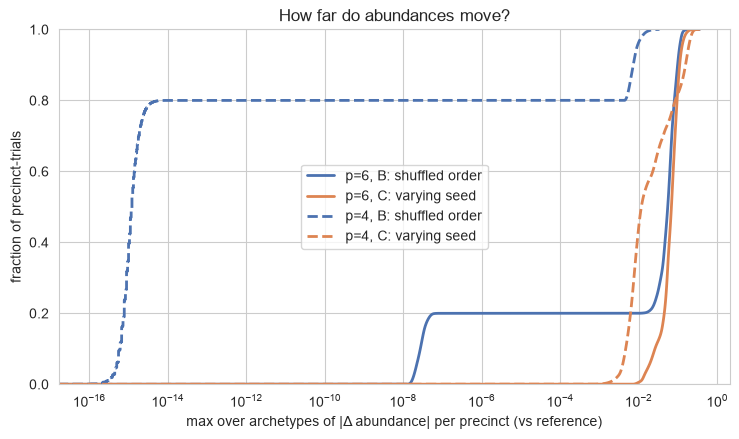

In [12]:
def per_precinct_maxdiff(p_run, arm):
    """Worst abundance shift per precinct, pooled over one arm's trials.

    Parameters
    ----------
    p_run : int
        Which experiment (archetype count) to read from `exp` / `matches`.
    arm : {'B', 'C'}
        Which arm's trials to evaluate. Archetypes are aligned with the
        spearman-Hungarian permutations.

    Returns
    -------
    diffs : ndarray, shape (n_trials * N,)
        For every (trial, precinct): the max over archetypes of
        |Δ abundance| vs the reference.
    """
    ref_ab = exp[p_run]['ref']['abundances']
    perms = matches[p_run, arm, 'spearman'][1]
    return np.concatenate([
        np.abs(res['abundances'][perm, :] - ref_ab).max(axis=0)
        for res, perm in zip(exp[p_run][arm], perms)])


fig, ax = plt.subplots(figsize=(7.5, 4.5))
colors = {'B': '#4C72B0', 'C': '#DD8452'}      # color = arm
styles = dict(zip(PS, ['-', '--']))            # linestyle = p
for p_run in PS:
    for arm in ['B', 'C']:
        d = per_precinct_maxdiff(p_run, arm)
        # clip at 1e-16 so bitwise-identical trials (diff = 0) still render on the log axis
        sns.ecdfplot(x=np.maximum(d, 1e-16), ax=ax, color=colors[arm], ls=styles[p_run],
                     lw=2, label=f'p={p_run}, {"B: shuffled order" if arm == "B" else "C: varying seed"}')
        print(f'p={p_run} arm {arm}: median={np.median(d):.2e}, '
              f'99th pct={np.percentile(d, 99):.2e}, max={d.max():.2e}')
ax.set_xscale('log')
ax.set_xlabel('max over archetypes of |Δ abundance| per precinct (vs reference)')
ax.set_ylabel('fraction of precinct-trials')
ax.set_title('How far do abundances move?')
ax.legend()
plt.tight_layout()

## Conclusions

**At `p = 6` precinct order changes the solution; at `p = 4` it essentially doesn't.**
The instability is degeneracy of the decomposition, not an ordering artifact per se.

**p = 6 (config):**
- Order shuffling with a fixed seed hops between a handful of *discrete* alternative
  solutions (trials 0 & 1 identical to each other, likewise 5 & 8; two trials reproduce
  the reference to ≲ 1e-7). All fit identically (RMSE 0.033695–0.033696 across 21 runs),
  so the data does not single out one solution.
- Ordering sensitivity ≈ seed sensitivity (mean matched Spearman 0.85 vs 0.78): both are
  symptoms of the same near-degenerate optimum.
- Archetypes 1 and 3 are the unstable ones; abundance maps are more robust than loadings
  except for archetypes 0/3 (min Pearson r ≈ 0.48–0.58).

**p = 4 (notebook 08's min-pairwise-distance choice):**
- **Order sensitivity all but vanishes.** 8/10 shuffles reproduce the reference
  endmembers *bitwise*; the other two differ by max |Δ loading| ≈ 0.10 (loading scale
  ≈ 1.5). Matched top-12 Jaccard is 1.000 for every archetype in every trial — the same
  12-candidate slates, always — and abundance maps are essentially exact
  (median per-precinct shift ~1e-15, min Pearson r ≥ 0.996).
- Seed sensitivity also shrinks but does not vanish (Arm C: min matched Spearman 0.675,
  one trial with |Δ loading| ≈ 0.91), so for publication-grade runs the seed still
  matters more than the ordering.
- Every metric and the greedy matcher agree 100% on the archetype correspondence —
  at `p = 4` the matching is unambiguous.
- The price: RMSE rises from 0.0337 to 0.0386 (~15%) — but that fit difference buys
  solutions that are actually reproducible.

**On the metrics (RBO / weighted τ / top-12 Jaccard vs Spearman):**
- All four (plus cosine) agree on *who matches whom* in 87–100% of assignments at
  `p = 6` and 100% at `p = 4`, so the choice of metric does not change the matching
  story — only how harshly disagreement is scored.
- The top-weighted metrics expose what Spearman smooths over: at `p = 6` the worst
  matched pairs score Spearman ≈ 0.20 but RBO ≈ 0.16 and **top-12 Jaccard ≈ 0.14 — the
  "same" archetype electing a mostly different 12-candidate slate**. Spearman's higher
  values are propped up by agreement in the long tail of no-hope candidates. Weighted τ
  is the gentlest of the rank family (min 0.37) because it still integrates the whole
  ordering. For headline claims ("archetype X's slate"), top-12 Jaccard is the most
  honest reporting metric; RBO is the best single top-weighted summary.

**Practical upshot:** run the production analysis at `p = 4`, where the archetypes are
unique up to machine precision under reordering and unambiguous to match — consistent
with notebook 08's distinctness criterion. Anything at `p = 6` needs
consensus/ensemble treatment and top-weighted (not Spearman) similarity reporting.